# L5 Data Cleaning & EDA

- Structure
  
  - File Formats (csv, tsv, json)

  - Variable Types

- Granularity & Temporality

- Faithfulness

  - Missing Values

<div style="background-color:#3b82f630; padding:12px 16px; border-left:5px solid #3b82f6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Definition:</strong> **Data Cleaning 数据清洗 / Data Wrangling 数据整理**

- The process of transforming raw data to facilitate subsequent analysis

	- May address issues like:
  
    	- Unclear structure & formatting

		- Missing & corrupted values
		
		- Unit conversions, etc.

- 简而言之就是做菜前要“备菜”

</div>

<div style="background-color:#3b82f630; padding:12px 16px; border-left:5px solid #3b82f6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Definition:</strong> **Exploratory Data Analysis (EDA) 数据探索**

- The process of understanding a new dataset

- 就是扫一眼数据长啥样，关于啥的，算算简单的平均数，方差啥的统计指标有个简单的初步理解，看看有没有什么有意思的特征或问题可以进一步探索

</div>

- Just some fancy words

## 1 Structure

- We usually prefer **rectangular data** for data analysis (i.e. A tablelike structure of data **with rows and cols**)

	- Easy to manipulate & analyze

- A key goal of data cleaning is to **make initial data more rectangular**

There are 2 types of rectangular data

- **Tables (表)**: have named columns with **different data types** and are manipulated using data transformation languages

- **Matrices (矩阵)**: contain **numeric data** of the **same type** and are manipulated using linear algebra

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- Whether it contains different types of data is the key difference

- Matrices can be viewed as pure-number tables, which is a simple version of table

</div>

### File Formats

- There are many file types for storing structured data: TSV, JSON, XML, ASCII, SAS, etc

- We just introduce CSV, TSV, and JSON in lecture, you can learn others by yourself when encountering them

In [9]:
import pandas as pd
import numpy as np

**CSV (Comma-Separated Values)**

- Let's see the raw data before it is loaded into a df

- We can use `repr()` func to return raw string

In [1]:
with open("elections.csv", "r") as table:
    i = 0
    for row in table:
        print(repr(row))
        i += 1
        if i > 3:
            break

'Year,Candidate,Party,Popular vote,Result,%\n'
'1824,Andrew Jackson,Democratic-Republican,151271,loss,57.21012204\n'
'1824,John Quincy Adams,Democratic-Republican,113142,win,42.78987796\n'
'1828,Andrew Jackson,Democratic,642806,win,56.20392707\n'


- Each line is a **string**

- Each row (record) is delimited by a newline `\n`

- Each col (field) is delimited by a comma `,` (hence **comma-separated** values, csv)

In [10]:
pd.read_csv("elections.csv").head(5)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927
3,1828,John Quincy Adams,National Republican,500897,loss,43.796073
4,1832,Andrew Jackson,Democratic,702735,win,54.574789


**TSV (Tab-Separated Values)**

- Same logic as for csv
  
- The record (row) is delimited by `\n`

- The field (col) is delimited by tab character `\t`

In [5]:
with open("elections.txt", "r") as table:
    i = 0
    for row in table:
        print(repr(row))
        i += 1
        if i > 3:
            break

'\ufeffYear\tCandidate\tParty\tPopular vote\tResult\t%\n'
'1824\tAndrew Jackson\tDemocratic-Republican\t151271\tloss\t57.21012204\n'
'1824\tJohn Quincy Adams\tDemocratic-Republican\t113142\twin\t42.78987796\n'
'1828\tAndrew Jackson\tDemocratic\t642806\twin\t56.20392707\n'


In [12]:
# We can also use the read_csv function to read tsv
# But we need to specify the delimiter as string '\t'
pd.read_csv("elections.txt", sep='\t').head(3)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927


<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **How does `pandas` differentiate a delimiter `,` and a actual text `,` like in `8,900`?**

- It uses [quotechar parameter](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) to solve this

**quotechar: *str (length 1), optional***

Character used to denote the start and end of a quoted item.

Quoted items can include the delimiter and it will be ignored.

Only **one character** (length 1) is allowed

**e.g.**

`quotechar='"'`

- It means `"` is the sign of the start & end

```
"London, UK"
↑          ↑
start      end
```
</div>

**JSON (JavaScript Object Notation)**

- It is similar to a Python dictionary, generally a nested dict

In [13]:
with open("elections.json", "r") as table:
    i = 0
    for row in table:
        print(row)
        i += 1
        if i > 8:
            break

[

 {

   "Year": 1824,

   "Candidate": "Andrew Jackson",

   "Party": "Democratic-Republican",

   "Popular vote": 151271,

   "Result": "loss",

   "%": 57.21012204

 },



In [15]:
pd.read_json('elections.json').head(3)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927


### *EDA with JSON (Demo)

- To get a JSON file containing information about the current members of Congress from California, you could use the following API call:

- https://api.congress.gov/v3/member/CA?api_key=[INSERT_KEY]&limit=250&format=json&currentMember=True

- You can instantly sign up for a congress.gov API key [here](https://gpo.congress.gov/sign-up/). Once you have your key, replace `[INSERT_KEY]` above with your key, and enter the API call as a URL in your browser to access the JSON file

- API keys are used to track how much a given user engages with the API
  
  - There might be limits to the number of API calls (e.g., congress.gov API limits to 5,000 calls per hour)
  
  - Or a cost for API calls (e.g., using the OpenAI API for programmatically using ChatGPT)

In [5]:
congress_file = "ca-congress-members.json"
print(type(congress_file))

# Inspect the first five lines of the file
with open(congress_file, "r") as f:
    for i, row in enumerate(f):
        print(row)
        if i >= 4: break

<class 'str'>
{

    "members": [

        {

            "bioguideId": "G000607",

            "depiction": {



In [2]:
import json

# Import the JSON file into Python as a dictionary
with open(congress_file, "rb") as f:
    congress_json = json.load(f)

type(congress_json)

dict

In [6]:
# Grab the list corresponding to the `members` key in the JSON dictionary, 
# and then grab the first element of this list.
# In a moment, we'll see how we knew to use the key `members`, and that
# the resulting object is a list.
congress_json['members'][0]

{'bioguideId': 'G000607',
 'depiction': {'imageUrl': 'https://www.congress.gov/img/member/6a29d4f81c6ce0de6fbae1f7_200.jpg'},
 'district': 1,
 'name': 'Gallagher, James',
 'partyName': 'Republican',
 'state': 'California',
 'terms': {'item': [{'chamber': 'House of Representatives',
    'startYear': 2026}]},
 'updateDate': '2026-08-09T07:40:25Z',
 'url': 'https://api.congress.gov/v3/member/G000607?format=json'}

- How should we probe a **nested dictionary** like congress_json?

- We can start by identifying the top-level keys of the dictionary

In [7]:
# Grab the top-level keys of the JSON dictionary
congress_json.keys()

dict_keys(['members', 'pagination', 'request'])

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **`meta` Key**

- You’ll often see a top-level meta key in JSON files
  
- It refers to metadata (data about the data). Metadata are often maintained alongside the data

</div>

In [8]:
type(congress_json['members'])

list

In [9]:
congress_json['members'][:2]

[{'bioguideId': 'G000607',
  'depiction': {'imageUrl': 'https://www.congress.gov/img/member/6a29d4f81c6ce0de6fbae1f7_200.jpg'},
  'district': 1,
  'name': 'Gallagher, James',
  'partyName': 'Republican',
  'state': 'California',
  'terms': {'item': [{'chamber': 'House of Representatives',
     'startYear': 2026}]},
  'updateDate': '2026-08-09T07:40:25Z',
  'url': 'https://api.congress.gov/v3/member/G000607?format=json'},
 {'bioguideId': 'F000483',
  'depiction': {'attribution': 'Image courtesy of the Member',
   'imageUrl': 'https://www.congress.gov/img/member/6a0f0dcb69b12040cf77e337_200.jpg'},
  'district': 30,
  'name': 'Friedman, Laura',
  'partyName': 'Democratic',
  'state': 'California',
  'terms': {'item': [{'chamber': 'House of Representatives',
     'startYear': 2025}]},
  'updateDate': '2026-08-09T07:40:25Z',
  'url': 'https://api.congress.gov/v3/member/F000483?format=json'}]

In [10]:
print(congress_json['pagination'])
print(congress_json['request'])

{'count': 53}
{'contentType': 'application/json', 'format': 'json'}


- The two other elements of `congress_json` don’t have the same structure as `congress_json['members']`

- Hence they cannot belong in a df containing `members` (Since inconsistancy prevents convertion)

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> **pd.read_json(json_file) may not work**

- The json can be not consistant in the formats

**e.g.**

- Say a JSON file looks like this:

```
{
    "pagination": {
        "count": 250,
        "next": "..."
    },

    "request": {
        "format": "json"
    },

    "members": [
        {"name": "A", "state": "CA"},
        {"name": "B", "state": "NY"},
        {"name": "C", "state": "TX"}
    ]
}
```

- Pandas can parse it successfully but don't know how to transform this unshaped data into one rectangular table

</div>

In [12]:
# This line intentionally produces an error
import pandas as pd
pd.read_json(congress_file)

ValueError: Mixing dicts with non-Series may lead to ambiguous ordering.

- But it is doable to extract one element which is aligned with the df format

In [13]:
# Convert dictionary to DataFrame
congress_df = pd.DataFrame(congress_json['members'])
congress_df.head()

,bioguideId,depiction,district,name,partyName,state,terms,updateDate,url
0,G000607,{'imageUrl': 'https://www.congress.gov/img/mem...,1.0,"Gallagher, James",Republican,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:25Z,https://api.congress.gov/v3/member/G000607?for...
1,F000483,{'attribution': 'Image courtesy of the Member'...,30.0,"Friedman, Laura",Democratic,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:25Z,https://api.congress.gov/v3/member/F000483?for...
2,F000480,{'attribution': 'Image courtesy of the Member'...,20.0,"Fong, Vince",Republican,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:25Z,https://api.congress.gov/v3/member/F000480?for...
3,C001123,{'attribution': 'Image courtesy of the Member'...,31.0,"Cisneros, Gilbert Ray",Democratic,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:25Z,https://api.congress.gov/v3/member/C001123?for...
4,M001225,{'attribution': 'Image courtesy of the Member'...,15.0,"Mullin, Kevin",Democratic,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:24Z,https://api.congress.gov/v3/member/M001225?for...


### Other Data Formats

- Some other data may not seem tabular, but they actually can be transformed into matrix form

	- **Image** Data: Used for medical diagnosis

	- **Audio** Data: Used for speech recognition, sentiment analysis

	- **Video** Data: Used for object tracking, facial recognition

	- **Text**: Used for LLMs, document review

### Variable Types

- Variables are **columns**

- A var is a measurement of a particular concept **with 2 properties:**

	- **Data type / Storage type**: int? float? boolean? str? etc.
    	
		- It affects which funcs can be used

	- **Variable type / Feature type**: Conceptualized measurement of information, the meaning in the reality, the statistical meaning

		- It affects how to interpret and what operations need to perform

- Generally we can categorize vars into 2 overarching types:

	- **Quantitative** variables

	- **Qualitative** variables / **Categorical** variables
  	
    	- **Ordinal** qualitative variables
    	
		- **Nominal** qualitative variables

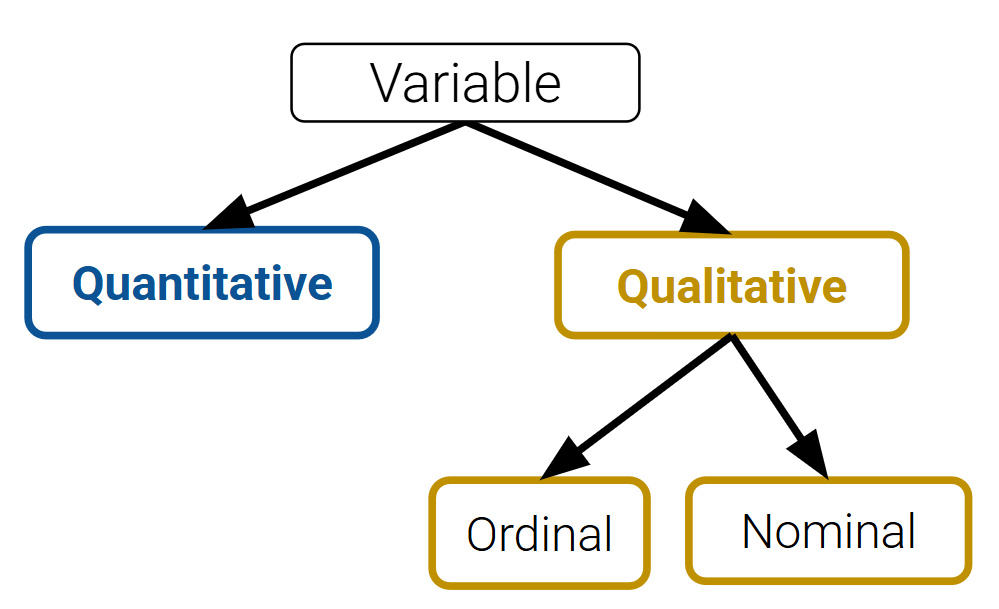

## 2 Granularity & Temporality

### Granularity (粒度)

- The granularity of a dataset is **what a single row represents**

- It reflects the **level of detail** included in the data

### Temporality（时间性）

- The temporality of a dataset describes the **periodicity** over which the data was collected as well as **when the data was most recently collected or updated**

- Time and date fields of a dataset could represent:

	- When the "event" happened?
	
	- When the data was collected and entered into system?
	
	- When the data was copied into database?

- To better undeerstand temporality, we need to **standardize the time zone and time format**

- The convention for standardized time is the **Coordinated Universal Time (UTC)**, an international time standard measured at 0 degrees latitude that stays consistent throughout the year (no daylight savings)

**`pandas' dt` Accessors (DataTime)**

In [16]:
calls = pd.read_csv("Berkeley_PD_-_Calls_for_Service.csv")
calls.head()

,CASENO,OFFENSE,EVENTDT,EVENTTM,CVLEGEND,CVDOW,InDbDate,Block_Location,BLKADDR,City,State
0,21014296,THEFT MISD. (UNDER $950),04/01/2021 12:00:00 AM,10:58,LARCENY,4,06/15/2021 12:00:00 AM,"Berkeley, CA\n(37.869058, -122.270455)",NaN,Berkeley,CA
1,21014391,THEFT MISD. (UNDER $950),04/01/2021 12:00:00 AM,10:38,LARCENY,4,06/15/2021 12:00:00 AM,"Berkeley, CA\n(37.869058, -122.270455)",NaN,Berkeley,CA
2,21090494,THEFT MISD. (UNDER $950),04/19/2021 12:00:00 AM,12:15,LARCENY,1,06/15/2021 12:00:00 AM,"2100 BLOCK HASTE ST\nBerkeley, CA\n(37.864908,...",2100 BLOCK HASTE ST,Berkeley,CA
3,21090204,THEFT FELONY (OVER $950),02/13/2021 12:00:00 AM,17:00,LARCENY,6,06/15/2021 12:00:00 AM,"2600 BLOCK WARRING ST\nBerkeley, CA\n(37.86393...",2600 BLOCK WARRING ST,Berkeley,CA
4,21090179,BURGLARY AUTO,02/08/2021 12:00:00 AM,6:20,BURGLARY - VEHICLE,1,06/15/2021 12:00:00 AM,"2700 BLOCK GARBER ST\nBerkeley, CA\n(37.86066,...",2700 BLOCK GARBER ST,Berkeley,CA


- `EVENTDT` stands for the date when the event took place

- `EVENTTM` stands for the time of day the event took place (in 24-hr format)

- `InDbDate` is the date this call is recorded onto the database

- **They are stored as strings here**, need transforming into `datatime`

In [17]:
calls["EVENTDT"] = pd.to_datetime(calls["EVENTDT"])
calls.head()

/var/folders/2t/f3t7qgfn0b52xhlj1dvj417c0000gn/T/ipykernel_46813/874729699.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  calls["EVENTDT"] = pd.to_datetime(calls["EVENTDT"])


,CASENO,OFFENSE,EVENTDT,EVENTTM,CVLEGEND,CVDOW,InDbDate,Block_Location,BLKADDR,City,State
0,21014296,THEFT MISD. (UNDER $950),2021-04-01,10:58,LARCENY,4,06/15/2021 12:00:00 AM,"Berkeley, CA\n(37.869058, -122.270455)",NaN,Berkeley,CA
1,21014391,THEFT MISD. (UNDER $950),2021-04-01,10:38,LARCENY,4,06/15/2021 12:00:00 AM,"Berkeley, CA\n(37.869058, -122.270455)",NaN,Berkeley,CA
2,21090494,THEFT MISD. (UNDER $950),2021-04-19,12:15,LARCENY,1,06/15/2021 12:00:00 AM,"2100 BLOCK HASTE ST\nBerkeley, CA\n(37.864908,...",2100 BLOCK HASTE ST,Berkeley,CA
3,21090204,THEFT FELONY (OVER $950),2021-02-13,17:00,LARCENY,6,06/15/2021 12:00:00 AM,"2600 BLOCK WARRING ST\nBerkeley, CA\n(37.86393...",2600 BLOCK WARRING ST,Berkeley,CA
4,21090179,BURGLARY AUTO,2021-02-08,6:20,BURGLARY - VEHICLE,1,06/15/2021 12:00:00 AM,"2700 BLOCK GARBER ST\nBerkeley, CA\n(37.86066,...",2700 BLOCK GARBER ST,Berkeley,CA


- We can use `dt` to get months

In [18]:
calls["EVENTDT"].dt.month.head()

0    4
1    4
2    4
3    2
4    2
Name: EVENTDT, dtype: int32

- Also which day of the week the date is on (周几)

In [19]:
calls["EVENTDT"].dt.dayofweek.head()

0    3
1    3
2    0
3    5
4    0
Name: EVENTDT, dtype: int32

- We can also use `dt` to switch time zones, convert time back to UNIX/POSIX time etc.

- More func can see the documentation on [`.dt` accessor](https://pandas.pydata.org/docs/user_guide/basics.html#basics-dt-accessors) & [time series/date functionality](https://pandas.pydata.org/docs/user_guide/timeseries.html#)

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **UNIX/POSIX Time**

- Can be thought as "From a pre-determined time, how many seconds have gone so far?"

- The starting time is **Unix Epoch (Unix 纪元)**: 1970-01-01 00:00:00 UTC

```
1970-01-01 00:00:00 UTC → Unix time = 0
1970-01-01 00:00:01 UTC → Unix time = 1
1970-01-01 00:01:00 UTC → Unix time = 60
1970-01-02 00:00:00 UTC → Unix time = 86400
```

- We call the `int` like 86400 a **Unix Timestamp (Unix 时间戳)**

- Compared to common time format, this way **doesn't need to worry about time zone** since everywhere at the same moment shares the same Unix timestamp
</div>

## 3 Faithfulness

- To make models work, we need to make sure the data we use is faithful to reality (i.e. our data **accurately captures the “real world”**)

Some common issues:

- **Unrealistic or “incorrect” values**
  - such as negative counts, locations that don’t exist, or dates set in the future

- **Violations of obvious dependencies**
  - like an age that does not match a birthday

- **Clear signs that data was entered by hand**
  - which can lead to spelling errors or fields that are incorrectly shifted

- **Signs of data falsification**
  - such as fake email addresses or repeated use of the same names

- **Duplicated records or fields**
  - containing the same information

- **Truncated data**
  - e.g. Microsoft Excel would limit the number of rows to 655536 and the number of columns to 255



Some solutions:

- **Spelling errors**: apply *corrections* or *drop* records that aren’t in a dictionary

- **Time zone inconsistencies**: *convert to a common time zone* (e.g. UTC)

- **Duplicated records or fields**: identify and *eliminate duplicates (using primary keys)*

- **Unspecified or inconsistent units**: infer the units and check that values are in reasonable ranges in the data

### Missing Values

**Solutions**

- Drop the records
  
  - But can introduce the risk of inducting bias (i.e. the corrupt records are systematically related to some features of interest of the data)

- Keep the data as `NaN`

- Imputation

  - Infer the missing values
  
    - Average
    
	- Hot deck
    	
		- One missing value → one imputed observed value → one completed dataset
	
	- Regression
	
	- Multiple
  	
    	- One missing value → multiple plausible values → multiple completed datasets → combine the analyses

---
[Reference](https://ds100.org/course-notes/eda/)